# 06 - Improved Simulation

Runs the proposed adaptive predictive model under the same conditions as the baseline.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
STEPS = 600
RUNS = 150
config = SimulationConfig()
engine = SimulationEngine(config=config)
improved_df = engine.run(steps=STEPS, runs=RUNS, mode='improved', seed=2026)
improved_time = summarize_by_time(improved_df)
print('Rows:', len(improved_df))
print(performance_summary(improved_df))
improved_df.head()

Rows: 90000
{'mean_reliability': 0.6584777777777778, 'failure_rate': 0.3415222222222222, 'mean_production': 0.9359733835005439, 'production_variance': 0.04646367372991522, 'mean_accuracy': 0.5039532645279556, 'mean_load': 5.980253043677135, 'mean_throughput': 0.4621591074355299}


,unit_state_vector,unit_state_mean,gamma,planned_production,production_rate,throughput,transmission_accuracy,reliability,failure,avg_load,max_load,gateway_load,gateway_utilization,avg_utilization,max_utilization,overload_risk,congestion_memory,time,run,mode
0,"[2, 3, 2, 2]",2.25,1.08,4.698,1.041647,0.331851,0.318583,1.0,0.0,3.171208,8.248731,8.248731,1.352251,1.081952,1.352251,0.352251,0.022475,0,0,improved
1,"[3, 3, 2, 1]",2.25,0.62,2.635,0.940509,0.405007,0.430626,1.0,0.0,2.587656,6.703481,6.703481,1.098931,0.886665,1.120433,0.120433,0.024070,1,0,improved
2,"[2, 3, 2, 0]",1.75,0.82,2.747,1.100840,0.524069,0.476063,1.0,0.0,2.406485,6.198187,6.198187,1.016096,0.826845,1.101879,0.101879,0.022771,2,0,improved
3,"[2, 1, 2, 0]",1.25,0.92,2.346,1.091020,0.551506,0.505495,1.0,0.0,2.247032,5.903880,5.903880,0.967849,0.766007,0.967849,0.000000,0.018672,3,0,improved
4,"[2, 1, 2, 2]",1.75,1.00,3.550,1.091803,0.425879,0.390070,1.0,0.0,2.770000,7.211973,7.211973,1.182291,0.946599,1.182291,0.182291,0.022265,4,0,improved


In [3]:
improved_df.to_csv(DATASET_DIR / 'improved_dataset.csv', index=False)
improved_time.to_csv(DATASET_DIR / 'improved_time_summary.csv', index=False)
print('Saved improved outputs to', DATASET_DIR)

Saved improved outputs to /Users/ketantripathi/codes/ICC/iot_project/outputs/datasets


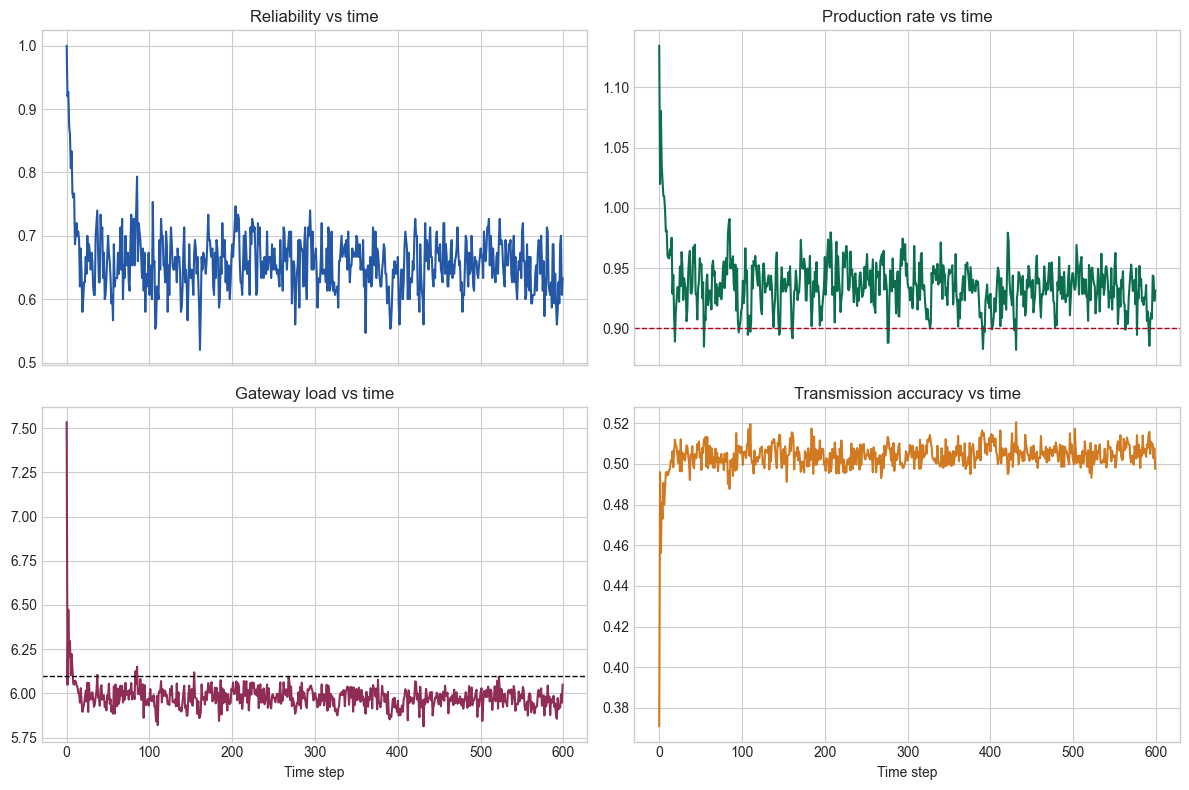

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()
axes[0].plot(improved_time['time'], improved_time['reliability'], color='#2457a6')
axes[0].set_title('Reliability vs time')
axes[1].plot(improved_time['time'], improved_time['production_rate'], color='#0b6e4f')
axes[1].axhline(config.demand, color='#b00020', linestyle='--', linewidth=1)
axes[1].set_title('Production rate vs time')
axes[2].plot(improved_time['time'], improved_time['gateway_load'], color='#8f2d56')
axes[2].axhline(config.gateway_capacity, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Gateway load vs time')
axes[2].set_xlabel('Time step')
axes[3].plot(improved_time['time'], improved_time['transmission_accuracy'], color='#d17a22')
axes[3].set_title('Transmission accuracy vs time')
axes[3].set_xlabel('Time step')
fig.tight_layout()
fig.savefig(GRAPH_DIR / '06_improved_performance.png', dpi=160)
plt.show()